# `wf_external_transfer` — 타인 송금 워크플로우 실행 노트북

잔액조회(01·02)가 "읽기"였다면 송금은 **돈이 실제로 움직이는 실행**입니다.
그만큼 안전장치가 겹겹이 있고, 사용자와의 상호작용(interrupt)도 4종류입니다.

## 잔액조회와 다른 점

| interrupt 종류 | 스텝 | 묻는 것 |
|---|---|---|
| 되묻기 (input) | ask_recipient / ask_amount_input / ask_account_selection | 누락 정보 |
| 경고 확인 (warning) | show_transfer_warning | 고액 송금 진행 여부 |
| **승인 (approval)** | show_transfer_review | 송금 카드 최종 승인/취소/수정 |
| **인증 (auth)** | request_user_authentication | 본인 인증 |

## 안전장치 (실행까지 통과해야 하는 관문)

1. 금액 정규화 + **1회 한도**(5,000만원) 검사 — `verify_amount`
2. 출금 계좌 **잔액 확인** (실시간 재조회) — `check_balance`
3. **송금 정책 검사** — 1,000만원 이상 차단 / 100만원 이상 경고 — `run_transfer_guardrail`
4. **사용자 승인 카드** — 승인/취소/수취인·금액·계좌 수정 — `create_approval`
5. **본인 인증** (mock) — `request_user_authentication`
6. **실행 직전 재검사** — 승인 내용과 실행 내용 일치 + 잔액 재확인 — `run_pre_execution_guardrail`
7. 감사 로그 — `write_audit_log`

이 노트북의 출력은 `OPENAI_API_KEY` **없이** 실행한 결과입니다.
슬롯 추출은 LLM이 1순위이고 정규식/키워드는 폴백이라, 키가 없으면
폴백 경로로 완주합니다 (검증·실행 로직은 항상 코드가 담당).

## Part 0. 환경 설정

`transfer_money`는 mock 원장(`MOCK_ACCOUNTS`)의 잔액을 **실제로 차감**합니다.
모듈 전역이 변하는 상태성이 있으므로, 시나리오마다 `reset_balances()`로
원장을 복원합니다 (테스트도 같은 방식으로 격리 — `agent/tests/conftest.py`).

In [51]:
import copy

from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command

from agent.data.mock_bank import MOCK_ACCOUNTS, MOCK_RECIPIENTS
from agent.graph import build_graph
from agent.service import _new_state

_SNAPSHOT = copy.deepcopy(MOCK_ACCOUNTS)


def reset_balances() -> None:
    """mock 원장을 초기 상태로 복원한다."""
    MOCK_ACCOUNTS.clear()
    MOCK_ACCOUNTS.update(copy.deepcopy(_SNAPSHOT))


def show_balances(label: str = "") -> None:
    accounts = MOCK_ACCOUNTS["user_001"]
    info = " / ".join(f"{a['account_name']} {a['balance']:,}원" for a in accounts)
    print(f"💰 잔액{label}: {info}")


print("등록된 수취인:")
for r in MOCK_RECIPIENTS["user_001"]:
    print(f"  - {r['name']} ({r['bank']} {r['account_number']})")
show_balances()

등록된 수취인:
  - 김철수 (국민은행 123-456-789012)
  - 이영희 (신한은행 110-123-456789)
💰 잔액: 입출금통장 1,200,000원 / 생활비통장 430,000원


## Part 1. 워크플로우 구조

송금은 스텝 25개, 라우트 53개짜리 큰 워크플로우입니다. 전부
`config/workflows.yaml`(시트 v2)에서 옵니다.

In [52]:
import yaml

from agent.paths import WORKFLOWS_PATH

with open(WORKFLOWS_PATH, encoding="utf-8") as f:
    wf = yaml.safe_load(f)["wf_external_transfer"]

print(f"steps {len(wf['steps'])}개 / routes {len(wf['routes'])}개\n")
print("=== STEPS ===")
for step in wf["steps"]:
    print(f"  {step['step_order']:>2}. {step['step_id']:32s} [{step['step_type']}]")

steps 25개 / routes 53개

=== STEPS ===
   1. extract_transfer_slots           [tool]
   2. check_recipient_input            [tool]
   3. ask_recipient                    [input]
   4. resolve_recipient_input          [tool]
   5. verify_recipient_account         [tool]
   6. show_invalid_recipient_account   [response]
   8. check_amount_input               [tool]
   9. ask_amount                       [input]
  10. verify_amount                    [tool]
  12. verify_from_account              [tool]
  13. ask_from_account                 [input]
  14. check_balance                    [tool]
  15. show_insufficient_balance        [response]
  16. run_transfer_guardrail           [guardrail]
  17. show_transfer_warning            [response]
  18. show_transfer_blocked            [response]
  19. review_transfer                  [approval]
  21. show_transfer_cancelled          [response]
  22. authenticate_user                [auth]
  24. show_authentication_failed       [response]
  25. 

> ⚠️ 이 그래프는 커서 mermaid.ink(GET, URL 길이 제한)로는 렌더링이 안 되고
> (HTTP 414), POST를 받는 kroki.io로 렌더링합니다. 인터넷이 필요합니다.

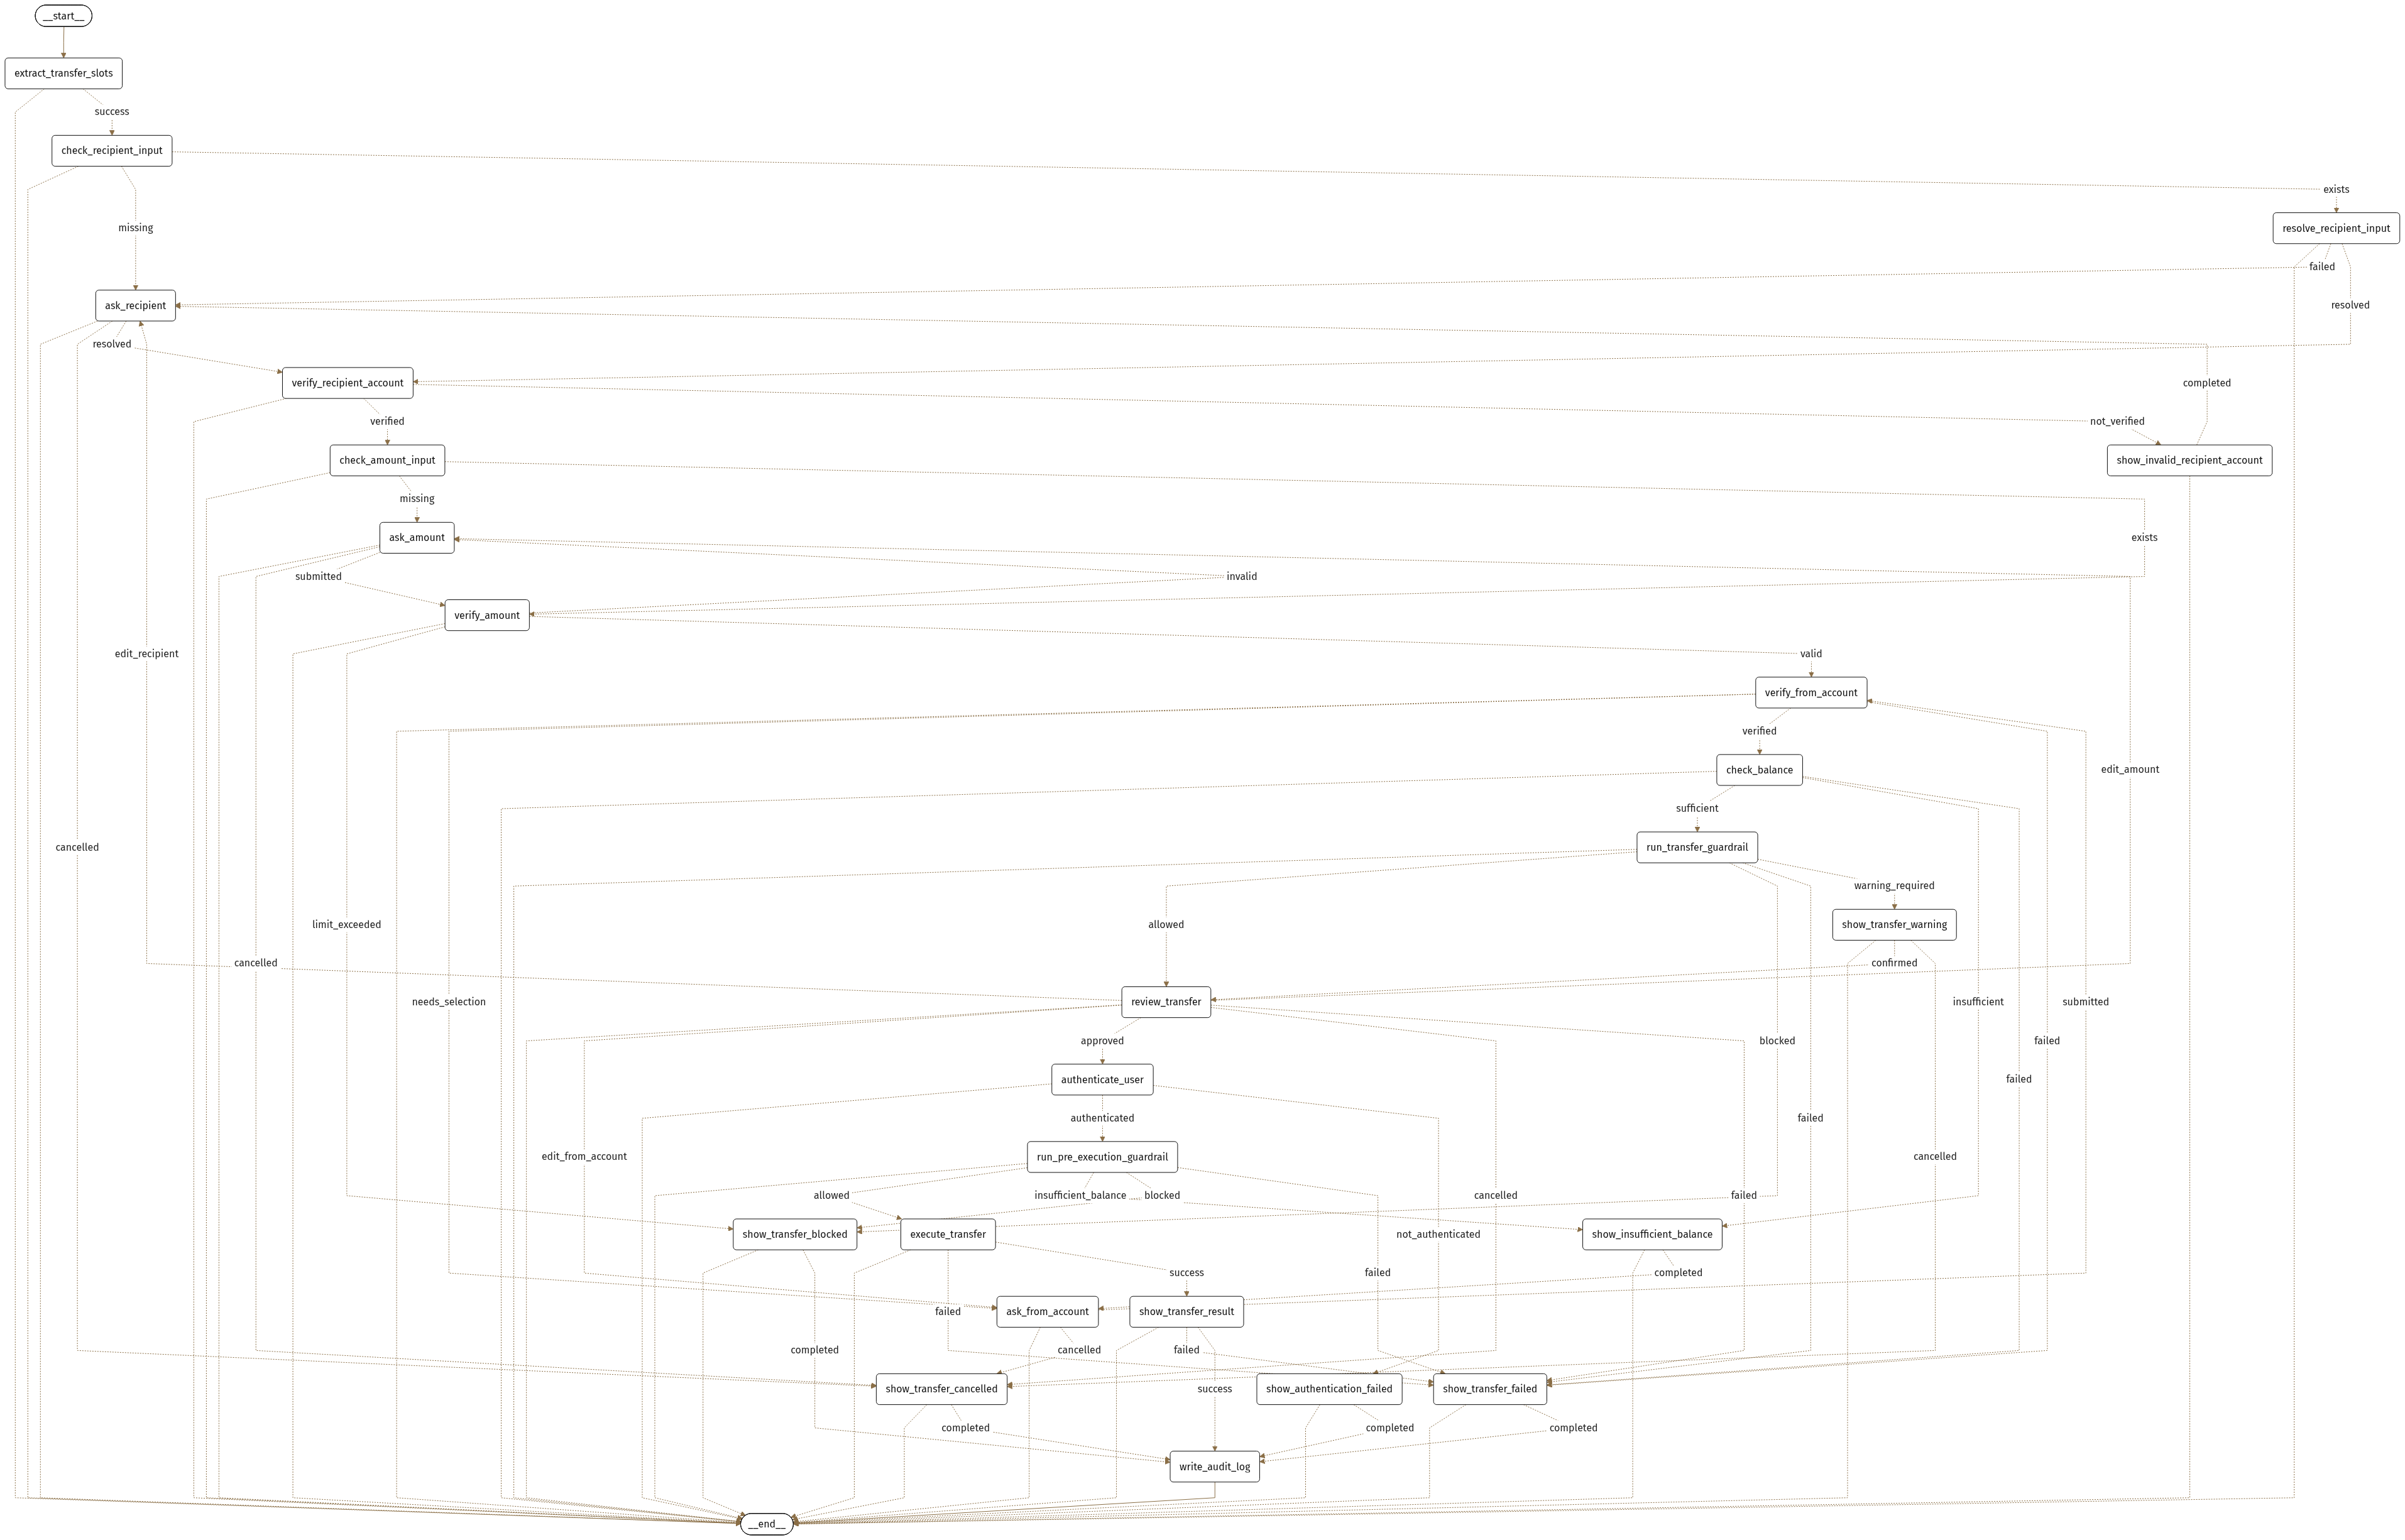

In [53]:
import urllib.request

from IPython.display import Image, display
from langchain_core.runnables.graph import NodeStyles

from agent.subgraph_builder import build_workflow_graph

sub = build_workflow_graph("wf_external_transfer", wf)
mermaid_src = sub.get_graph().draw_mermaid(
    node_colors=NodeStyles(
        default="fill:#ffffff,stroke:#111111,color:#111111,line-height:1.2",
        first="fill:#ffffff,stroke:#111111,color:#111111",
        last="fill:#ffffff,stroke:#111111,color:#111111",
    ),
    frontmatter_config={
        "config": {
            "theme": "base",
            "themeVariables": {
                "background": "#ffffff",
                "primaryColor": "#ffffff",
                "primaryTextColor": "#222222",
                "primaryBorderColor": "#8B6F47",
                "lineColor": "#8B6F47",
            },
        }
    },
)

try:
    request = urllib.request.Request(
        "https://kroki.io/mermaid/png",
        data=mermaid_src.encode(),
        headers={"Content-Type": "text/plain", "User-Agent": "Mozilla/5.0"},
    )
    with urllib.request.urlopen(request, timeout=60) as response:
        display(Image(response.read()))
except Exception as e:
    print(f"PNG 렌더링 실패({type(e).__name__}) — mermaid 소스로 대체:\n")
    print(mermaid_src)

### 설계 포인트: tool이 직접 `interrupt()`를 부른다

되묻기(input 스텝)는 엔진이 interrupt를 걸지만, **승인·인증·경고는 tool
함수가 직접 `interrupt()`를 호출**합니다 (`bank_tools.create_approval` 등).

- 재개되면 노드가 처음부터 다시 실행되므로 interrupt 이전 코드는 프롬프트
  조립 같은 **멱등 작업**만 둡니다
- 답변은 키워드로 파싱해 route_key(approved/cancelled/edit_* ...)를 정합니다
- 승인 게이트에서 해석할 수 없는 답변은 **보수적으로 취소** 처리합니다
  (금융 앱 원칙 — 애매하면 실행하지 않는다)

## Part 2. 시나리오 워크스루

대화 헬퍼를 만듭니다. `start()`로 새 대화를 열고, 멈추면(⏸) `resume()`으로
답합니다.

In [54]:
import textwrap
import uuid

GRAPH = build_graph(checkpointer=MemorySaver())


def _show(result: dict) -> None:
    if result.get("__interrupt__"):
        prompt = result["__interrupt__"][0].value["prompt"]
        print("⏸ 에이전트 (입력 대기):")
        print(textwrap.indent(prompt, "   "))
    else:
        print(f"✅ 에이전트: {result.get('final_response')}")


def start(text: str):
    config = {"configurable": {"thread_id": uuid.uuid4().hex[:8]}}
    print(f"👤 {text}")
    result = GRAPH.invoke(_new_state(text, "user_001"), config)
    _show(result)
    return config, result


def resume(config: dict, reply: str) -> dict:
    print(f"👤 {reply}")
    result = GRAPH.invoke(Command(resume=reply), config)
    _show(result)
    return result


def show_trace(result: dict) -> None:
    print("실행 경로:")
    for t in result.get("execution_trace", []):
        print(f"  {t['step']} [{t['route_key']}]")


print("헬퍼 준비 완료")

헬퍼 준비 완료


### 시나리오 1 — 완전 정보 해피패스

수취인·금액이 다 있는 발화 → 검증 체인 통과 → **승인 카드** → **본인 인증**
→ 실행. 잔액이 실제로 줄어드는 것까지 확인합니다.

In [56]:
reset_balances()
show_balances(" (송금 전)")
print()

config, r = start("123-456-789012로 5만원 보내줘")

💰 잔액 (송금 전): 입출금통장 1,200,000원 / 생활비통장 430,000원

👤 123-456-789012로 5만원 보내줘
⏸ 에이전트 (입력 대기):
   누구에게 보낼까요? 이름 또는 계좌번호를 입력해주세요.


In [31]:
r = resume(config, "승인")

👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.


In [32]:
r = resume(config, "인증완료")
print()
show_balances(" (송금 후)")

👤 인증완료
✅ 에이전트: 김철수님에게 50,000원을 송금했습니다. 거래번호: txn_63d4526f

💰 잔액 (송금 후): 입출금통장 1,200,000원 / 생활비통장 430,000원


In [33]:
show_trace(r)

실행 경로:
  extract_transfer_slots [success]
  check_recipient_input [exists]
  resolve_recipient_input [resolved]
  verify_recipient_account [verified]
  check_amount_input [exists]
  verify_amount [valid]
  verify_from_account [verified]
  check_balance [sufficient]
  run_transfer_guardrail [allowed]
  show_transfer_review [approved]
  request_user_authentication [authenticated]
  run_pre_execution_guardrail [allowed]
  execute_transfer [success]
  generate_transfer_response [success]
  write_audit_log [logged]


trace 읽기: `extract_transfer_slots [success]`부터
`run_pre_execution_guardrail [allowed]` → `execute_transfer [success]`까지,
안전장치 7단계를 전부 지나온 것이 보입니다.

### 시나리오 2 — 정보가 없으면 되묻기 연쇄

"송금해줘"만 말하면 수취인 → 금액 → 승인 → 인증, interrupt 4연쇄가
이어집니다.

In [34]:
reset_balances()
config, r = start("송금해줘")

👤 송금해줘
⏸ 에이전트 (입력 대기):
   누구에게 보낼까요? 이름 또는 계좌번호를 입력해주세요.


In [35]:
r = resume(config, "김철수")

👤 김철수
⏸ 에이전트 (입력 대기):
   얼마를 송금할까요?


In [36]:
r = resume(config, "3만원")

👤 3만원
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 30,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.


In [37]:
r = resume(config, "승인")

👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.


In [38]:
r = resume(config, "인증완료")

👤 인증완료
✅ 에이전트: 김철수님에게 30,000원을 송금했습니다. 거래번호: txn_e4475781


### 시나리오 3 — 한도 초과 즉시 차단

1회 한도(5,000만원) 초과는 interrupt 없이 검증 단계에서 바로 차단됩니다.

In [39]:
reset_balances()
config, r = start("김철수한테 6000만원 보내줘")
print()
show_trace(r)

👤 김철수한테 6000만원 보내줘
✅ 에이전트: 1회 송금 한도(50,000,000원)를 초과해 진행할 수 없습니다. 요청 금액: 60,000,000원

실행 경로:
  extract_transfer_slots [success]
  check_recipient_input [exists]
  resolve_recipient_input [resolved]
  verify_recipient_account [verified]
  check_amount_input [exists]
  verify_amount [limit_exceeded]
  show_transfer_blocked [completed]
  write_audit_log [logged]


> 참고: 정책 차단(1,000만원 이상, `run_transfer_guardrail`)은 mock 잔액
> (최대 125만원)으로는 잔액 확인에서 먼저 걸려 자연스럽게 도달할 수 없습니다.
> 그 경로는 단위 테스트(`test_transfer_tools.py`)가 커버합니다.

### 시나리오 4 — 잔액 부족 → 다른 계좌 선택

생활비통장(43만원)에서 50만원을 보내려 하면 잔액 부족 → 계좌 재선택으로
이어집니다.

In [40]:
reset_balances()
config, r = start("생활비통장에서 이영희한테 50만원 보내줘")

👤 생활비통장에서 이영희한테 50만원 보내줘
⏸ 에이전트 (입력 대기):
   생활비통장 잔액(430,000원)이 송금 금액(500,000원)보다 부족해요. 다른 계좌를 선택해주세요.
     1. 입출금통장 (잔액 1,250,000원)
     2. 생활비통장 (잔액 430,000원)


In [41]:
r = resume(config, "1번")  # 입출금통장(125만원) 선택

👤 1번
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 이영희 (신한은행 110-123-456789)
     보내는 계좌: 입출금통장
     금액       : 500,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.


In [42]:
r = resume(config, "승인")
r = resume(config, "인증완료")
print()
show_balances()

👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.
👤 인증완료
✅ 에이전트: 이영희님에게 500,000원을 송금했습니다. 거래번호: txn_03c62cd2

💰 잔액: 입출금통장 750,000원 / 생활비통장 430,000원


### 시나리오 5 — 승인 단계 취소 (잔액 불변)

승인 카드에서 "취소"하면 아무것도 실행되지 않습니다. 해석할 수 없는 답변도
보수적으로 취소됩니다.

In [43]:
reset_balances()
config, r = start("김철수한테 5만원 보내줘")
r = resume(config, "취소")
print()
show_balances(" (변화 없음)")

👤 김철수한테 5만원 보내줘
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 50,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.
👤 취소
✅ 에이전트: 송금을 취소했습니다.

💰 잔액 (변화 없음): 입출금통장 1,250,000원 / 생활비통장 430,000원


### 시나리오 6 — 승인 카드에서 금액 수정

"금액 수정" → 새 금액 입력 → **검증 체인이 처음부터 다시** 돌고 새 승인
카드가 나옵니다 (수정된 값도 똑같이 한도/잔액/정책 검사를 통과해야 함).

In [44]:
reset_balances()
config, r = start("김철수한테 5만원 보내줘")
r = resume(config, "금액 수정")

👤 김철수한테 5만원 보내줘
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 50,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.
👤 금액 수정
⏸ 에이전트 (입력 대기):
   새 송금 금액을 입력해주세요 (예: 3만원).


In [45]:
r = resume(config, "10만원")  # 새 승인 카드에 100,000원이 표시된다

👤 10만원
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 100,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.


In [46]:
r = resume(config, "승인")
r = resume(config, "인증완료")
print()
print("재검증 체인 확인 (verify_amount가 두 번):")
steps = [t["step"] for t in r["execution_trace"]]
print("  verify_amount 실행 횟수:", steps.count("verify_amount"))
print("  check_balance 실행 횟수:", steps.count("check_balance"))

👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.
👤 인증완료
✅ 에이전트: 김철수님에게 100,000원을 송금했습니다. 거래번호: txn_1ac80b07

재검증 체인 확인 (verify_amount가 두 번):
  verify_amount 실행 횟수: 2
  check_balance 실행 횟수: 2


### 시나리오 7 — 고액 송금 경고 (100만원 이상)

정책 검사에서 `warning_required` → 주의 안내 확인을 거쳐야 승인 카드로
넘어갑니다.

In [47]:
reset_balances()
config, r = start("김철수한테 120만원 보내줘")

👤 김철수한테 120만원 보내줘
⏸ 에이전트 (입력 대기):
   주의가 필요한 송금입니다. 금액: 1,200,000원
   평소보다 큰 금액이에요. 진행하려면 '확인', 중단하려면 '취소'를 입력해주세요.


In [48]:
r = resume(config, "확인")  # 주의 안내 통과 -> 승인 카드
r = resume(config, "승인")
r = resume(config, "인증완료")

👤 확인
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 1,200,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.
👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.
👤 인증완료
✅ 에이전트: 김철수님에게 1,200,000원을 송금했습니다. 거래번호: txn_fb121908


### 시나리오 8 — 본인 인증 실패

승인까지 했어도 인증이 안 되면 실행되지 않습니다.

In [49]:
reset_balances()
config, r = start("김철수한테 5만원 보내줘")
r = resume(config, "승인")
r = resume(config, "안 할래")
print()
show_balances(" (변화 없음)")

👤 김철수한테 5만원 보내줘
⏸ 에이전트 (입력 대기):
   [송금 확인]
     받는 분    : 김철수 (국민은행 123-456-789012)
     보내는 계좌: 입출금통장
     금액       : 50,000원
   진행하려면 '승인', 중단하려면 '취소',
   수정하려면 '수취인 수정' / '금액 수정' / '계좌 수정'을 입력해주세요.
👤 승인
⏸ 에이전트 (입력 대기):
   본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.
👤 안 할래
✅ 에이전트: 본인 인증이 완료되지 않아 송금을 진행할 수 없습니다.

💰 잔액 (변화 없음): 입출금통장 1,250,000원 / 생활비통장 430,000원


## Part 3. HTTP API로 같은 흐름 실행

지금까지의 interrupt들이 HTTP에서는 전부 `status: "waiting_input"`으로
번역됩니다. 클라이언트는 직전 응답의 `thread_id`를 회송하면 됩니다.

경로: `frontend(useAgentChat) → backend(/api/v1/agent/chat) → agent(/chat)`

In [50]:
import warnings

from fastapi.testclient import TestClient

from agent.main import app

warnings.filterwarnings("ignore")

reset_balances()
client = TestClient(app)


def chat(body: dict) -> dict:
    result = client.post("/chat", json=body).json()
    marker = " (thread_id 회송)" if body.get("thread_id") else ""
    print(f">> {body['message']}{marker}")
    print(f"   status={result['status']}  prompt_for={result['prompt_for']}")
    print(f"   reply: {result['reply'].splitlines()[0]}")
    print()
    return result


r1 = chat({"message": "김철수한테 5만원 보내줘"})
r2 = chat({"message": "승인", "thread_id": r1["thread_id"]})
r3 = chat({"message": "인증완료", "thread_id": r2["thread_id"]})
show_balances(" (HTTP 송금 후)")

>> 김철수한테 5만원 보내줘
   status=waiting_input  prompt_for=transfer.approval_decision
   reply: [송금 확인]

>> 승인 (thread_id 회송)
   status=waiting_input  prompt_for=transfer.auth_result
   reply: 본인 인증을 진행해주세요 (지문 / Face ID / 비밀번호). 완료 후 '인증완료'를 입력해주세요.

>> 인증완료 (thread_id 회송)
   status=completed  prompt_for=None
   reply: 김철수님에게 50,000원을 송금했습니다. 거래번호: txn_f416cbcb

💰 잔액 (HTTP 송금 후): 입출금통장 1,200,000원 / 생활비통장 430,000원


## 정리

| 확인한 것 | 위치 |
|---|---|
| 송금 tool 15개 (Tool_v2 계약, 결정적) | `agent/src/agent/tools/bank_tools.py` |
| tool 내부 interrupt (승인/인증/경고) | `create_approval` 등 |
| 승인 요약 vs 실행 내용 대조 | `run_pre_execution_guardrail` |
| 잔액 실시간 재조회·차감 | `check_balance`, `transfer_money` |
| HTTP waiting_input / thread_id 회송 | `agent/src/agent/service.py` |

**같은 시나리오의 자동 테스트**: `agent/tests/test_transfer_flow.py` (10종)

**남은 과제**
- 답변 파싱을 키워드에서 LLM 보강으로 확장 (현재도 키 있으면 매칭/추출 일부 LLM)
- mock 원장 → mock-financial-service HTTP 연동
- MemorySaver → persistent checkpointer (승인 대기 세션의 재시작 생존)